# Семинар 1. Классические задачи CV в спорте
Подготовили: Моисеев Михаил, Дурыгин Олег

Данные: отрезок 30 секунд из матча из датасета Soccernet GSR

## Installation

In [ ]:
# Install dependencies (only in Colab; no repo clone)
!pip install -q ultralytics opencv-python-headless matplotlib lap>=0.5.12 scikit-learn sahi
print("Installation done.")

# Player detection with YOLO + ByteTrack

This tutorial loads **YOLO** (Ultralytics), runs **player detection** on football match frames, and adds **ByteTrack** tracking for persistent IDs. No private repo — only `ultralytics`, `opencv`, `matplotlib`.

- **Detection**: YOLO native results (boxes: xyxy, conf, cls).
- **Tracking**: ByteTrack via `model.track(..., tracker="bytetrack.yaml", persist=True)`.
- **Pretrained** `yolov8m.pt` or your custom `.pt` path.

## 1. Imports and helper

We use only `ultralytics` (YOLO + ByteTrack), `opencv-python`, `matplotlib`. Detections stay in Ultralytics native format (Results with .boxes).

## 2. Load YOLO player detector

- **`MODEL_PATH = "yolov8m.pt"`**: pretrained COCO; we keep only the **person** class for players.
- **Custom**: set `MODEL_PATH` to the path of your `.pt` weights file.

In [ ]:
import re
import zipfile
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from tqdm.notebook import tqdm

In [ ]:
# Pretrained COCO (person = players) or path to your .pt weights
MODEL_PATH = "yolov8x.pt"
CONF_THRESHOLD = 0.55
# COCO class 0 = person; use None to keep all classes
CLASSES_FILTER = [0] if MODEL_PATH in ("yolov8m.pt", "yolov8n.pt", "yolov8s.pt", "yolov8l.pt", "yolov8x.pt") else None

model = YOLO(MODEL_PATH)
print("Detector ready.")

## 3. Load frames from a zip (e.g. on Google Drive)

In Colab: mount Google Drive and set `ZIP_PATH` to your zip of frames (e.g. `"/content/drive/MyDrive/frames.zip"`). Frames are extracted and loaded in **logical order** (natural sort by filename: frame_001.jpg, frame_002.jpg, …).

In [ ]:
!gdown 1R3lTyOlCYoQb5EOcrMIQ4yJn0_z1lYhS

In [ ]:
# Natural sort
def _natural_sort_key(s: str):
    return [int(x) if x.isdigit() else x.lower() for x in re.split(r"(\d+)", s)]

IMAGE_EXTENSIONS = [".jpg", ".png"]
ZIP_PATH = "SNGS-141.zip"
EXTRACT_DIR = Path("/content/frames")
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

# List images and sort logically
image_paths = []
for p in EXTRACT_DIR.rglob("*"):
    if p.suffix.lower() in IMAGE_EXTENSIONS:
        image_paths.append(p)
image_paths = sorted(image_paths, key=lambda p: _natural_sort_key(p.name))

# Load as RGB in order
frames = []
for p in image_paths:
    img = cv2.imread(str(p))
    if img is not None:
        frames.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

print(f"Loaded {len(frames)} frames from {ZIP_PATH} (order: {[p.name for p in image_paths[:3]]} ...)")
if not frames:
    raise FileNotFoundError(f"No images found in {ZIP_PATH}. Use a zip of .jpg/.png frames.")

## 4. Run detection on a single frame

Read one frame and run the detector. Results are Ultralytics `Results` (use `result.boxes`: xyxy, conf, cls).

In [ ]:
# Use first frame from the loaded list
frame_rgb = frames[0]
results = model.predict(frame_rgb, imgsz=640, conf=CONF_THRESHOLD, classes=CLASSES_FILTER, verbose=False)
result = results[0]
print(f"Detected {len(result.boxes)} players (frame 0)")
print("Boxes (xyxy, conf, cls):", result.boxes.xyxy.shape if result.boxes.data.numel() else 0)

## 5. Visualize detection boxes

Draw boxes from `result.boxes`

In [ ]:
def draw_boxes(image: np.ndarray, result, color=(255, 0, 0), show_track_id: bool = True) -> np.ndarray:
    """Draw bounding boxes from Ultralytics result.boxes (xyxy, conf, cls, optional id). RGB image."""
    vis = image.copy()
    if result.boxes is None or result.boxes.data.numel() == 0:
        return vis
    names = result.names
    xyxy = result.boxes.xyxy.cpu().numpy()
    conf = result.boxes.conf.cpu().numpy()
    cls = result.boxes.cls.cpu().numpy().astype(int)
    ids = result.boxes.id.cpu().numpy() if result.boxes.id is not None else np.full(len(xyxy), -1)
    for i in range(len(xyxy)):
        x1, y1, x2, y2 = map(int, xyxy[i])
        c = conf[i]
        name = names.get(int(cls[i]), "?")
        tid = int(ids[i]) if ids[i] >= 0 else None
        if show_track_id and tid is not None:
            label = f"id={tid}"
        else:
            label = f"{c:.2f}"
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(vis, (x1, y1 - th - 4), (x1 + tw, y1), color, -1)
        cv2.putText(vis, label, (x1, y1 - 2), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    return vis


vis_frame = draw_boxes(frame_rgb, result, show_track_id=False)
plt.figure(figsize=(14, 8))
plt.imshow(vis_frame)
plt.axis("off")
plt.title("Player detection")
plt.tight_layout()
plt.show()

## 5.1 Inference YOLO+SAHI
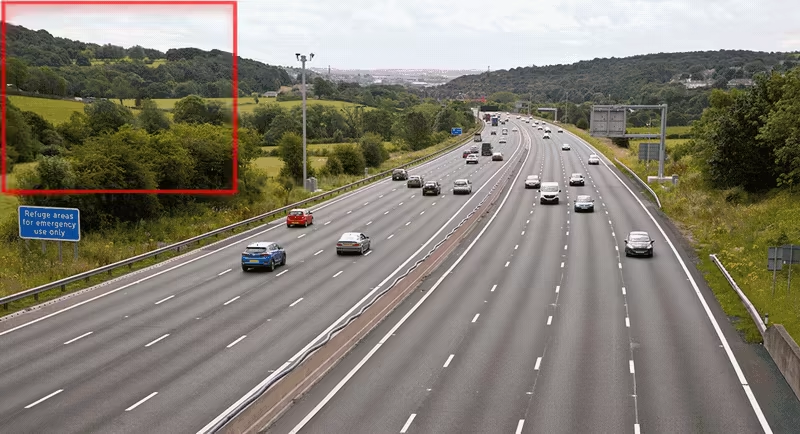

In [ ]:
from sahi.predict import get_sliced_prediction
from sahi import AutoDetectionModel

detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=MODEL_PATH,
    confidence_threshold=CONF_THRESHOLD,
    device='cuda:0',
)

result = get_sliced_prediction(
    frame_rgb,
    detection_model,
    slice_height=512,
    slice_width=512,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
)

In [ ]:
from IPython.display import Image

result.export_visuals(export_dir="demo_data/")
Image("demo_data/prediction_visual.png")

## 6. Batch detection on multiple frames

Process several frames at once for better GPU utilization.

In [ ]:
NUM_FRAMES = 50  # total frames to process
BATCH_SIZE = 8    # process this many at a time to avoid OOM

batch_frames = frames[:NUM_FRAMES]
if not batch_frames:
    raise RuntimeError("No frames loaded from zip.")

batch_results = []
for start in tqdm(range(0, len(batch_frames), BATCH_SIZE)):
    chunk = batch_frames[start : start + BATCH_SIZE]
    results = model.predict(chunk, imgsz=640, conf=CONF_THRESHOLD, classes=CLASSES_FILTER, verbose=False)
    batch_results.extend(results)

print(f"Processed {len(batch_results)} frames")
for i, r in enumerate(batch_results[:5]):  # show first 5
    n = len(r.boxes) if r.boxes is not None and r.boxes.data.numel() else 0
    print(f"  Frame {i}: {n} detections")
if len(batch_results) > 5:
    print(f"  ...")

## 7. ByteTrack tracking

Run **ByteTrack** with `model.track(..., tracker="bytetrack.yaml", persist=True)` so each player gets a stable **track ID** across frames. Process frames sequentially to keep tracker state.

In [ ]:
# Track with ByteTrack (frame-by-frame with persist=True)
tracked_frames = []
tracked_results = []
for frame_rgb in tqdm(batch_frames):
    results = model.track(
        frame_rgb,
        imgsz=640,
        conf=CONF_THRESHOLD,
        classes=CLASSES_FILTER,
        tracker="bytetrack.yaml",
        persist=True,
        verbose=False,
    )
    tracked_frames.append(frame_rgb)
    tracked_results.append(results[0])

print(f"Tracked {len(tracked_results)} frames with ByteTrack (IDs in result.boxes.id)")

Visualize a few tracked frames with **track ID** labels.

In [ ]:
n_show = min(4, len(tracked_frames))
STEP = 10
fig, axes = plt.subplots(n_show, 1, figsize=(16, 7 * n_show))
if n_show == 1:
    axes = [axes]
for i in range(n_show):
    vis = draw_boxes(tracked_frames[i*STEP], tracked_results[i*STEP], show_track_id=True)
    axes[i].imshow(vis)
    axes[i].set_title(f"Frame {i*STEP} — ByteTrack IDs")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## 8. Export result to video

Combine the tracked frames (with bounding boxes and IDs drawn) into a single video file. In Colab the file is written to `/content/`; you can download it from the file browser.

In [ ]:
try:
    import google.colab
    OUTPUT_VIDEO_PATH = "/content/tracking_result.mp4"
except ImportError:
    OUTPUT_VIDEO_PATH = "./tracking_result.mp4"
FPS = 30

# Use ByteTrack results (or change to batch_frames + batch_results for detection-only)
frames_to_export = tracked_frames
results_to_export = tracked_results

h, w = frames_to_export[0].shape[:2]
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, FPS, (w, h))

for frame_rgb, result in zip(frames_to_export, results_to_export):
    vis = draw_boxes(frame_rgb, result, show_track_id=True)
    writer.write(cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))

writer.release()
print(f"Saved video: {OUTPUT_VIDEO_PATH} ({len(frames_to_export)} frames, {FPS} fps)")

# Team classification
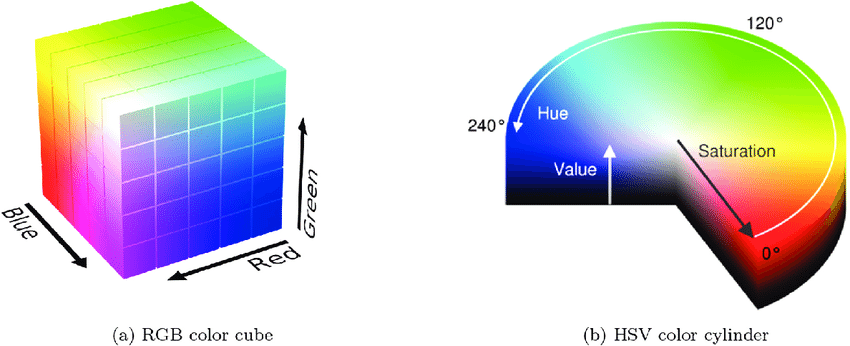

## Cluster players by RGB

### Mean RGB excluding the grass

In [ ]:
# --- RGB heuristics for grass (tune if needed) ---
# Exclude pixels that look like grass (dominant green + not too dark).
GREEN_DOMINANCE = 20        # how much G should exceed R and B to be considered green
GREEN_MIN_G = 60            # minimum green channel to be considered grass
MIN_BRIGHTNESS = 50         # exclude very dark pixels from being classified as grass (or used at all)

def mean_rgb_excluding_green(crop_rgb):
    """
    Mean RGB of crop, excluding pixels that look like grass (green-dominant).
    Returns (mean_rgb, mask_accounted).
    mask_accounted: 255 = used for mean, 0 = excluded.
    """
    crop = crop_rgb.astype(np.uint8)

    r = crop[:, :, 0].astype(np.int16)
    g = crop[:, :, 1].astype(np.int16)
    b = crop[:, :, 2].astype(np.int16)

    # brightness proxy (simple)
    brightness = (r + g + b) // 3

    # grass: green is significantly higher than red and blue, and green is not tiny, and pixel not too dark
    is_green = (g >= GREEN_MIN_G) & ((g - r) >= GREEN_DOMINANCE) & ((g - b) >= GREEN_DOMINANCE) & (brightness >= MIN_BRIGHTNESS)

    # mask: 255 = accounted (non-green), 0 = excluded (green)
    mask_accounted = np.where(is_green, 0, 255).astype(np.uint8)

    pixels = crop.reshape(-1, 3).astype(np.float32)
    non_green = pixels[~is_green.ravel()]

    # If everything got filtered out, fall back to mean of the whole crop
    if non_green.size == 0:
        mean_rgb = pixels.mean(axis=0)
        mask_accounted[:] = 255
    else:
        mean_rgb = non_green.mean(axis=0)

    return mean_rgb, mask_accounted

### Mask exclusion visualization

In [ ]:
# Collect player crops and mean RGB (grass excluded)
FRAME_IDX = 30
frame, result = tracked_frames[FRAME_IDX], tracked_results[FRAME_IDX]
items = []
N_SAMPLES_VIS = 6

if result.boxes is None or result.boxes.data.numel() == 0:
    print("No players found")
else:
    xyxy = result.boxes.xyxy.cpu().numpy()
    for i in range(len(xyxy)):
        x1, y1, x2, y2 = map(int, xyxy[i])
        if x2 <= x1 or y2 <= y1:
            continue
        crop = frame[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        mean_rgb, mask_accounted = mean_rgb_excluding_green(crop)
        items.append((i, (x1, y1, x2, y2), mean_rgb))

# Random sample of crops+masks for visualization
rng = np.random.default_rng(42)
n_vis = min(N_SAMPLES_VIS, len(items))
sample_indices = rng.choice(len(items), size=n_vis, replace=False) if n_vis > 0 else []
crop_mask_samples = []
for j in sample_indices:
    _, (x1, y1, x2, y2), _ = items[j]
    crop = tracked_frames[FRAME_IDX][y1:y2, x1:x2]
    _, mask = mean_rgb_excluding_green(crop)
    crop_mask_samples.append((crop.copy(), mask.copy()))

# Visualize masks: white = pixels used for mean (accounted), black = grass excluded
n_vis = len(crop_mask_samples)
if n_vis > 0:
    fig, axes = plt.subplots(2, n_vis, figsize=(2 * n_vis, 4))
    if n_vis == 1:
        axes = axes.reshape(2, 1)
    for j in range(n_vis):
        crop, mask = crop_mask_samples[j]
        axes[0, j].imshow(crop)
        axes[0, j].set_title(f"Crop {j+1}")
        axes[0, j].axis("off")
        axes[1, j].imshow(mask, cmap="gray", vmin=0, vmax=255)
        axes[1, j].set_title("Accounted (white)\nExcluded (black)")
        axes[1, j].axis("off")
    plt.suptitle("Pixels accounted for mean RGB (white) vs grass excluded (black)", fontsize=11)
    plt.tight_layout()
    plt.show()

### Clusterization

In [ ]:
from sklearn.cluster import KMeans

# --- Clustering in RGB space ---
if len(items) < 2:
    print("Need at least 2 player crops to cluster.")
else:
    X = np.array([item[2] for item in items], dtype=np.float32)  # mean RGB per crop
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    # Map box_idx -> cluster label
    frame_box_label = {item[0]: int(labels[j]) for j, item in enumerate(items)}

    # Cluster centers already in RGB (0..255-ish floats). Clip + int for display.
    team_colors_rgb = []
    for c in kmeans.cluster_centers_:
        rgb = np.clip(c, 0, 255).astype(np.uint8)
        team_colors_rgb.append(tuple(map(int, rgb.tolist())))

    # Panel: cluster swatches + R-G scatter (or R-B / G-B if you prefer)
    fig = plt.figure(figsize=(14, 10))

    ax1 = fig.add_subplot(2, 1, 1)
    for k in range(2):
        ax1.add_patch(
            plt.Rectangle(
                (k * 0.45, 0.1), 0.35, 0.5,
                facecolor=np.array(team_colors_rgb[k]) / 255.0,
                edgecolor="black"
            )
        )
        ax1.text(k * 0.45 + 0.175, 0.05, f"Team {k}", ha="center", fontsize=12)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 0.7)
    ax1.axis("off")
    ax1.set_title("Cluster centers (RGB)")

    ax2 = fig.add_subplot(2, 1, 2)
    for k in range(2):
        m = labels == k
        color = tuple(np.array(team_colors_rgb[k]) / 255.0)
        ax2.scatter(X[m, 0], X[m, 1], color=color, s=15, alpha=0.7, label=f"Team {k}")
    ax2.set_xlabel("Red")
    ax2.set_ylabel("Green")
    ax2.set_title("Players in R-G space (B omitted)")
    ax2.legend()
    plt.tight_layout()
    plt.show()

### Teams Visualization

In [ ]:

# One frame with boxes colored by team
show_frame_idx = FRAME_IDX
vis = tracked_frames[show_frame_idx].copy()
result = tracked_results[show_frame_idx]
if result.boxes is not None and result.boxes.data.numel() > 0:
    xyxy = result.boxes.xyxy.cpu().numpy()
    for i in range(len(xyxy)):
        label = frame_box_label.get(i, 0)
        x1, y1, x2, y2 = map(int, xyxy[i])
        color = team_colors_rgb[label]
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 3)
        cv2.putText(vis, f"T{label}", (x1, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
plt.figure(figsize=(14, 8))
plt.imshow(vis)
plt.axis("off")
plt.title(f"Frame {show_frame_idx} — boxes colored by cluster (Team 0 / Team 1)")
plt.tight_layout()
plt.show()

## Cluster players by HSV

### Mean HSV excluding the grass

In [ ]:
# HSV range for grass (OpenCV: H 0-179, S/V 0-255). Exclude these pixels when computing mean.
GREEN_H_MIN, GREEN_H_MAX = 35, 85   # hue range for green
SATURATION_MIN = 50                      # min saturation to count as grass
VALUE_MIN = 50

def mean_hsv_excluding_green(crop_rgb):
    """Mean HSV of crop, excluding pixels in the grass (green) range. Returns (mean_hsv, mask_accounted). mask_accounted: 255 = used for mean, 0 = excluded."""
    crop_hsv = cv2.cvtColor(crop_rgb, cv2.COLOR_RGB2HSV)
    h, s, v = crop_hsv[:, :, 0], crop_hsv[:, :, 1], crop_hsv[:, :, 2]
    is_green = (h >= GREEN_H_MIN) & (h <= GREEN_H_MAX) & (s >= SATURATION_MIN) & (v >= VALUE_MIN)
    mask_accounted = np.where(is_green, 0, 255).astype(np.uint8)
    pixels = crop_hsv.reshape(-1, 3)
    non_green = pixels[~is_green.ravel()]
    mean_hsv = non_green.mean(axis=0)
    return mean_hsv, mask_accounted

### Mask exclusion visualization

In [ ]:
# Collect player crops and mean HSV (grass excluded)
FRAME_IDX = 30
frame, result = tracked_frames[FRAME_IDX], tracked_results[FRAME_IDX]
items = []
N_SAMPLES_VIS = 6

if result.boxes is None or result.boxes.data.numel() == 0:
    print("No players found")
else:
    xyxy = result.boxes.xyxy.cpu().numpy()
    for i in range(len(xyxy)):
        x1, y1, x2, y2 = map(int, xyxy[i])
        if x2 <= x1 or y2 <= y1:
            continue
        crop = frame[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        mean_hsv, mask_accounted = mean_hsv_excluding_green(crop)
        items.append((i, (x1, y1, x2, y2), mean_hsv))

# Random sample of crops+masks for visualization
rng = np.random.default_rng(42)
n_vis = min(N_SAMPLES_VIS, len(items))
sample_indices = rng.choice(len(items), size=n_vis, replace=False)
crop_mask_samples = []
for j in sample_indices:
    _, (x1, y1, x2, y2), _ = items[j]
    crop = tracked_frames[FRAME_IDX][y1:y2, x1:x2]
    _, mask = mean_hsv_excluding_green(crop)
    crop_mask_samples.append((crop.copy(), mask.copy()))


# Visualize masks: white = pixels used for mean (accounted), black = grass excluded
n_vis = len(crop_mask_samples)
fig, axes = plt.subplots(2, n_vis, figsize=(2 * n_vis, 4))
if n_vis == 1:
    axes = axes.reshape(2, 1)
for j in range(n_vis):
    crop, mask = crop_mask_samples[j]
    axes[0, j].imshow(crop)
    axes[0, j].set_title(f"Crop {j+1}")
    axes[0, j].axis("off")
    axes[1, j].imshow(mask, cmap="gray", vmin=0, vmax=255)
    axes[1, j].set_title("Accounted (white)\nExcluded (black)")
    axes[1, j].axis("off")
plt.suptitle("Pixels accounted for mean HSV (white) vs grass excluded (black)", fontsize=11)
plt.tight_layout()
plt.show()

### Clusterization

In [ ]:
from sklearn.cluster import KMeans


if len(items) < 2:
    print("Need at least 2 player crops to cluster.")
else:
    X = np.array([item[2] for item in items])
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    # Map box_idx -> cluster label
    frame_box_label = {item[0]: labels[j] for j, item in enumerate(items)}

    # Cluster centers in HSV (H:0-179, S,V:0-255); convert to RGB for display
    team_colors_rgb = []
    for c in kmeans.cluster_centers_:
        h, s, v = np.clip(c, [0, 0, 0], [179, 255, 255])
        bgr = cv2.cvtColor(np.uint8([[[h, s, v]]]), cv2.COLOR_HSV2BGR)
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        team_colors_rgb.append(tuple(map(int, rgb[0, 0])))

    # Panel: cluster swatches + H-S scatter + one frame with boxes colored by team
    fig = plt.figure(figsize=(14, 10))
    # Row 1: color swatches and H-S scatter
    ax1 = fig.add_subplot(2, 1, 1)
    for k in range(2):
        ax1.add_patch(plt.Rectangle((k * 0.45, 0.1), 0.35, 0.5, facecolor=np.array(team_colors_rgb[k]) / 255, edgecolor="black"))
        ax1.text(k * 0.45 + 0.175, 0.05, f"Team {k}", ha="center", fontsize=12)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 0.7)
    ax1.axis("off")
    ax1.set_title("Cluster centers (HSV → RGB)")

    ax2 = fig.add_subplot(2, 1, 2)
    for k in range(2):
        mask = labels == k
        color = tuple(np.array(team_colors_rgb[k]) / 255)
        ax2.scatter(X[mask, 0], X[mask, 1], color=color, s=15, alpha=0.7, label=f"Team {k}")
    ax2.set_xlabel("Hue")
    ax2.set_ylabel("Saturation")
    ax2.set_title("Players in H-S space (V omitted)")
    ax2.legend()
    plt.tight_layout()
    plt.show()


### Teams Visualization

In [ ]:

# One frame with boxes colored by team
show_frame_idx = FRAME_IDX
vis = tracked_frames[show_frame_idx].copy()
result = tracked_results[show_frame_idx]
if result.boxes is not None and result.boxes.data.numel() > 0:
    xyxy = result.boxes.xyxy.cpu().numpy()
    for i in range(len(xyxy)):
        label = frame_box_label.get(i, 0)
        x1, y1, x2, y2 = map(int, xyxy[i])
        color = team_colors_rgb[label]
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 3)
        cv2.putText(vis, f"T{label}", (x1, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
plt.figure(figsize=(14, 8))
plt.imshow(vis)
plt.axis("off")
plt.title(f"Frame {show_frame_idx} — boxes colored by cluster (Team 0 / Team 1)")
plt.tight_layout()
plt.show()